# Impact of preprocessing steps
Evaluate the impact of different preprocessing steps on the vocabulary size of the dataset.
Necessity of original text for the evaluation.

In [1]:
import os
from pathlib import Path

import pandas as pd
from genai_detection.visualization import datasets
from genai_detection.config import CONFIG
from genai_detection.dataset_util import StudentEssayDatasetLoader

preproc_impact = pd.DataFrame(columns=["Student Essay", "Blog", "Gutenberg"])

# student data
path2student_essays = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.DATA_BASE_PATH
    / "student_essays/Intro2006"
)
student_essay_loader = StudentEssayDatasetLoader(path=path2student_essays)
student_essay_df = student_essay_loader._load_student_essays(min_num_words=0)[
    ["text", "task"]
]  # normally, texts < 700 words are filtered out after preprocessing
student_essay_texts = [
    t["text"] for t in student_essay_df.to_dict("records") if t["task"] != "Ass5"
]  # filter out Ass5 task cf. Koppel et Al. (2014)
print(f"student essay dataset: {len(student_essay_texts)} texts")


# Blog dataset
path2blog = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.DATA_BASE_PATH
    / "Blog_corpus/blogtext.csv"
)

blog_df = pd.read_csv(path2blog)
blog_texts = [t["text"] for t in blog_df.to_dict("records")]
print(f"Blog dataset: {len(blog_texts)} texts")


# Gutenberg dataset
path2gutenberg = (
    Path(os.getcwd()).resolve().parent / CONFIG.DATA_BASE_PATH / "gutenberg/"
)
gutenberg_texts = []
for file in path2gutenberg.glob("*.txt"):
    if "Complete_Works_of_William_Shakespeare" in file.name:
        # Skip the complete works of Shakespeare as it is way longer than other texts
        continue
    with open(file, "r", encoding="utf-8") as f:
        gutenberg_texts.append(f.read())
print(f"Gutenberg dataset: {len(gutenberg_texts)} texts")

[nltk_data] Downloading package punkt_tab to /Users/klara/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


student essay dataset: 3652 texts
Blog dataset: 681284 texts
Gutenberg dataset: 17 texts


Order of preprocessing steps:
1. decode any html entities (&amp; → &)
    `single_text = html.unescape(single_text)`

2. strip out html tags such as <p>, <br>, etc.
    `single_text = re.sub(r"<[^>]+>", "", single_text)`

3. remove play artifacts that:
    - contain only uppercase letters, spaces, and optionally dots or colons at the end
    - e.g. "PALAMON.", "FIRST LORD:", "KING"
    ```header_pattern = re.compile(r"^[A-Z\s]+[.:]?$", re.MULTILINE)
    single_text = re.sub(header_pattern, "", single_text)```

4. remove chapter artifacts:
   - ^\s*Chapter\s+\w+  — start of line, optional spaces, 'Chapter' + some word/number
   - \s*                — optional spaces (for line endings)
   - \n+                — one or more newlines (blank lines after header)
   ```chapter_pattern = re.compile(
        r"^\s*Chapter\s+\w+.*\n\s*\n", re.IGNORECASE | re.MULTILINE
    )
    single_text = re.sub(chapter_pattern, "", single_text)```
5. remove act and scene (play artifacts)
    ```single_text = re.sub(
        r"\s*ACT\s+\w+\b\.?", "", single_text, flags=re.IGNORECASE | re.MULTILINE
    )
    single_text = re.sub(
        r"^\s*SCENE\s+\w+\b\.?", "", single_text, flags=re.IGNORECASE | re.MULTILINE
    )```

6. remove brackets but keep content (play artifacts)
    `single_text = re.sub(r"\[(.*?)\]", r"\1", single_text, flags=re.DOTALL)`

7. remove underscores inside the extracted content (play artifacts)
    `single_text = re.sub(r"_+", "", single_text)`

8. remove trailing numbers (i.e. line numbers as play articfact); whitespace followed by digits at end of line
    `single_text = re.sub(r"\s+\d+\s*$", "", single_text, flags=re.MULTILINE)`

9. collapse all whitespace (including newlines) to single spaces and trim
    `single_text = re.sub(r"\s+", " ", single_text).strip()`

10. transliterate to ascii, dropping characters that can't be converted
    ```single_text = (
            unicodedata.normalize("NFKD", single_text)
            .encode("ascii", "ignore")
            .decode("ascii")
        )```

In [2]:
from genai_detection.detectors.impostor_base import ImpostorBase

imposter_base = ImpostorBase()


def get_vocab_size(texts):
    """
    Get the vocabulary size (in space-free character 4-grams) of a list of texts.
    """
    ngrams = [imposter_base.tokenize_char_ngrams(text, 4) for text in texts]
    vocab = set([ngram for ngram_list in ngrams for ngram in ngram_list])
    return len(vocab)


compl_student_essay_length = get_vocab_size(student_essay_texts)
compl_blog_length = get_vocab_size(blog_texts)
compl_gutenberg_length = get_vocab_size(gutenberg_texts)
preproc_impact.loc["0 before preprocessing"] = [
    compl_student_essay_length,
    compl_blog_length,
    compl_gutenberg_length,
]
display(preproc_impact)

,Student Essay,Blog,Gutenberg
0 before preprocessing,51816,1391117,78308


In [3]:
import html
import re
import unicodedata
from torch import t


# decode any html entities (&amp; → &)
student_step1 = [html.unescape(single_text) for single_text in student_essay_texts]
blog_step1 = [html.unescape(single_text) for single_text in blog_texts]
gutenberg_step1 = [html.unescape(single_text) for single_text in gutenberg_texts]
step1_student_essay_length = get_vocab_size(student_step1)
step1_blog_length = get_vocab_size(blog_step1)
step1_gutenberg_length = get_vocab_size(gutenberg_step1)
preproc_impact.loc["1 decode any html entities"] = [
    step1_student_essay_length,
    step1_blog_length,
    step1_gutenberg_length,
]

# strip out html tags such as <p>, <br>, etc.
student_step2 = [re.sub(r"<[^>]+>", "", single_text) for single_text in student_step1]
blog_step2 = [re.sub(r"<[^>]+>", "", single_text) for single_text in blog_step1]
gutenberg_step2 = [
    re.sub(r"<[^>]+>", "", single_text) for single_text in gutenberg_step1
]
step2_student_essay_length = get_vocab_size(student_step2)
step2_blog_length = get_vocab_size(blog_step2)
step2_gutenberg_length = get_vocab_size(gutenberg_step2)
preproc_impact.loc["2 strip out html tags"] = [
    step2_student_essay_length,
    step2_blog_length,
    step2_gutenberg_length,
]

# remove play artifacts that:
# - contain only uppercase letters, spaces, and optionally dots or colons at the end
# - e.g. "PALAMON.", "FIRST LORD:", "KING"
header_pattern = re.compile(r"^[A-Z\s]+[.:]?$", re.MULTILINE)
student_step3 = [
    re.sub(header_pattern, "", single_text) for single_text in student_step2
]
blog_step3 = [re.sub(header_pattern, "", single_text) for single_text in blog_step2]
gutenberg_step3 = [
    re.sub(header_pattern, "", single_text) for single_text in gutenberg_step2
]
step3_student_essay_length = get_vocab_size(student_step3)
step3_blog_length = get_vocab_size(blog_step3)
step3_gutenberg_length = get_vocab_size(gutenberg_step3)
preproc_impact.loc["3 remove play artifacts (e.g. `KING:`)"] = [
    step3_student_essay_length,
    step3_blog_length,
    step3_gutenberg_length,
]

# remove chapter artifacts:
# ^\s*Chapter\s+\w+  — start of line, optional spaces, 'Chapter' + some word/number
# \s*                — optional spaces (for line endings)
# \n+                — one or more newlines (blank lines after header)
chapter_pattern = re.compile(
    r"^\s*Chapter\s+\w+.*\n\s*\n", re.IGNORECASE | re.MULTILINE
)
student_step4 = [
    re.sub(chapter_pattern, "", single_text) for single_text in student_step3
]
gutenberg_step4 = [
    re.sub(chapter_pattern, "", single_text) for single_text in gutenberg_step3
]
blog_step4 = [re.sub(chapter_pattern, "", single_text) for single_text in blog_step3]
step4_student_essay_length = get_vocab_size(student_step4)
step4_blog_length = get_vocab_size(blog_step4)
step4_gutenberg_length = get_vocab_size(gutenberg_step4)
preproc_impact.loc["4 remove chapter artifacts"] = [
    step4_student_essay_length,
    step4_blog_length,
    step4_gutenberg_length,
]


# remove act and scene (play artifacts)
def remove_play_artifacts(single_text):
    single_text = re.sub(
        r"\s*ACT\s+\w+\b\.?", "", single_text, flags=re.IGNORECASE | re.MULTILINE
    )
    single_text = re.sub(
        r"^\s*SCENE\s+\w+\b\.?", "", single_text, flags=re.IGNORECASE | re.MULTILINE
    )
    # remove brackets but keep content (play artifacts)
    single_text = re.sub(r"\[(.*?)\]", r"\1", single_text, flags=re.DOTALL)
    # remove underscores inside the extracted content (play artifacts)
    single_text = re.sub(r"_+", "", single_text)
    # remove trailing numbers (i.e. line numbers as play articfact); whitespace followed by digits at end of line
    return re.sub(r"\s+\d+\s*$", "", single_text, flags=re.MULTILINE)


student_step5 = [remove_play_artifacts(single_text) for single_text in student_step4]
blog_step5 = [remove_play_artifacts(single_text) for single_text in blog_step4]
gutenberg_step5 = [
    remove_play_artifacts(single_text) for single_text in gutenberg_step4
]
step5_student_essay_length = get_vocab_size(student_step5)
step5_blog_length = get_vocab_size(blog_step5)
step5_gutenberg_length = get_vocab_size(gutenberg_step5)
preproc_impact.loc["5 remove play artifacts (e.g. `ACT`, `SCENE`)"] = [
    step5_student_essay_length,
    step5_blog_length,
    step5_gutenberg_length,
]

# collapse all whitespace (including newlines) to single spaces and trim
student_step6 = [
    re.sub(r"\s+", " ", single_text).strip() for single_text in student_step5
]
blog_step6 = [re.sub(r"\s+", " ", single_text).strip() for single_text in blog_step5]
gutenberg_step6 = [
    re.sub(r"\s+", " ", single_text).strip() for single_text in gutenberg_step5
]
step6_student_essay_length = get_vocab_size(student_step6)
step6_blog_length = get_vocab_size(blog_step6)
step6_gutenberg_length = get_vocab_size(gutenberg_step6)
preproc_impact.loc["6 collapse all whitespace"] = [
    step6_student_essay_length,
    step6_blog_length,
    step6_gutenberg_length,
]

# transliterate to ascii, dropping characters that can't be converted
student_step7 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in student_step6
]
blog_step7 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in blog_step6
]
gutenberg_step7 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in gutenberg_step6
]
step7_student_essay_length = get_vocab_size(student_step7)
step7_blog_length = get_vocab_size(blog_step7)
step7_gutenberg_length = get_vocab_size(gutenberg_step7)
preproc_impact.loc["7 transliterate to ascii"] = [
    step7_student_essay_length,
    step7_blog_length,
    step7_gutenberg_length,
]

# lowercase all texts
student_step8 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in student_step7
]
blog_step8 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in blog_step7
]
gutenberg_step8 = [
    unicodedata.normalize("NFKD", single_text).encode("ascii", "ignore").decode("ascii")
    for single_text in gutenberg_step7
]
step8_student_essay_length = get_vocab_size(student_step8)
step8_blog_length = get_vocab_size(blog_step8)
step8_gutenberg_length = get_vocab_size(gutenberg_step8)
preproc_impact.loc["8 lowercase"] = [
    step8_student_essay_length,
    step8_blog_length,
    step8_gutenberg_length,
]

In [4]:
display(preproc_impact)

,Student Essay,Blog,Gutenberg
0 before preprocessing,51816,1391117,78308
1 decode any html entities,51816,1373226,78308
2 strip out html tags,51816,1370921,78308
3 remove play artifacts (e.g. `KING:`),51816,1370903,77862
4 remove chapter artifacts,51816,1370903,77715
"5 remove play artifacts (e.g. `ACT`, `SCENE`)",51816,1340714,73206
6 collapse all whitespace,51816,1340714,73206
7 transliterate to ascii,51816,1066580,66310
8 lowercase,51816,1066580,66310


In [5]:
preproc_impact.to_csv(
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "datasets"
    / "preprocessed_steps_impact.csv",
    index_label="step",
)

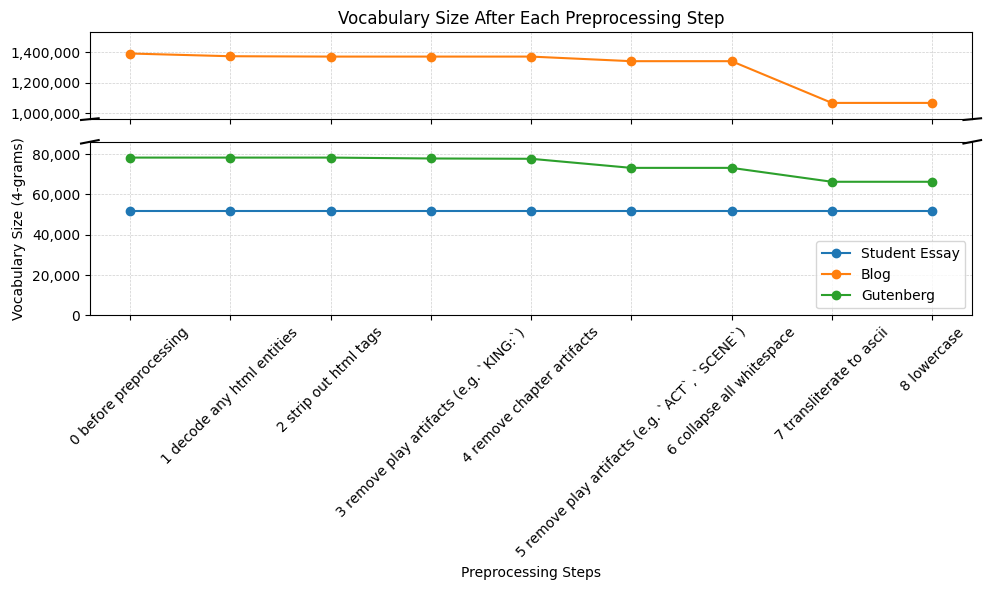

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, _: f"{int(x):,}")


# Create a figure with two y-axes (subplots) that share the x-axis
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6), gridspec_kw={"height_ratios": [1, 2]}
)

# Define the break points
break_low = int(preproc_impact["Gutenberg"].max() * 1.1)
break_high = int(preproc_impact["Blog"].min() * 0.9)

# Plot each series on both axes
for ax in [ax1, ax2]:
    ax.plot(
        preproc_impact.index,
        preproc_impact["Student Essay"],
        marker="o",
        label="Student Essay",
    )
    ax.plot(preproc_impact.index, preproc_impact["Blog"], marker="o", label="Blog")
    ax.plot(
        preproc_impact.index, preproc_impact["Gutenberg"], marker="o", label="Gutenberg"
    )

# Set the y-limits to create the "break"
ax1.set_ylim(break_high, preproc_impact["Blog"].max() * 1.1)
ax2.set_ylim(0, break_low)
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

# Add a diagonal break indicator
d = 0.01  # break size
kwargs = dict(transform=ax1.transAxes, color="k", clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axis
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and layout
ax2.set_xlabel("Preprocessing Steps")
ax2.set_ylabel("Vocabulary Size (4-grams)")
ax1.set_title("Vocabulary Size After Each Preprocessing Step")
ax2.set_xticks(range(len(preproc_impact.index)))
ax2.set_xticklabels(preproc_impact.index, rotation=45)

# Only show the legend once
ax2.legend(loc="lower right")
for ax in [ax1, ax2]:
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)


plt.tight_layout()
plt.savefig(
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "datasets"
    / "impact_preprocessing_steps.svg",
    bbox_inches="tight",
    format="svg",
)

plt.show()

For most datasets, lowercasing has no big impact on the vocabulary size, so it is not included in the preprocessing steps.